# 02 · EDA & data dictionary · **EXPLORE**

**Owner:** Jaime · **Status:** sandbox · **Reading order:** after `00` (framing) and `01` (ingestion)

**Step-by-step exploration of both finalists** — A (`hcp_task_with_behaviour`, 100 subj) and B (`hcp`,
339 subj) — before the Monday A-vs-B decision. Scan order:
load → columns → networks → conditions → target → basic visualisations, mirrored for A and B. Code style follows the
official NMA loaders ([`load_hcp_task_with_behaviour`](https://github.com/NeuromatchAcademy/course-content/blob/v3.0.2/projects/fMRI/load_hcp_task_with_behaviour.ipynb),
[`load_hcp`](https://github.com/NeuromatchAcademy/course-content/blob/v3.0.2/projects/fMRI/load_hcp.ipynb)).

## 0 · Data access & provenance

NMA-curated subset of the **Human Connectome Project** (HCP); requires accepting the
[HCP Data Use Terms](https://www.humanconnectome.org/study/hcp-young-adult/document/wu-minn-hcp-consortium-open-access-data-use-terms).
Raw data under `data/`, **gitignored** — never committed.

| Finalist | Official loader (how to download) | OSF files → local folder |
|---|---|---|
| **A** — 100 subj, task + behaviour | [`load_hcp_task_with_behaviour`](https://github.com/NeuromatchAcademy/course-content/blob/v3.0.2/projects/fMRI/load_hcp_task_with_behaviour.ipynb) | `hcp_task.tgz` → `data/A_load_hcp_task_with_behaviour/hcp_task/` |
| **B** — 339 subj, + resting-state | [`load_hcp`](https://github.com/NeuromatchAcademy/course-content/blob/v3.0.2/projects/fMRI/load_hcp.ipynb) | task, rest, covariates and atlas → `data/B_load_hcp/` (local task/atlas renames documented in `data/README.md`) |

The official project guide ([projects/fMRI](https://compneuro.neuromatch.io/projects/fMRI/README.html)) documents the
folder layout and helper functions.

## Setup

In [1]:
from pathlib import Path
import os, sys, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
JAIME = cwd if (cwd / "datasets.py").exists() else cwd / "sandbox" / "jaime"
ROOT = JAIME.parents[1]
sys.path.insert(0, str(JAIME))
import datasets as ds, preprocessing as pp, evaluation as ev

DATA = Path(os.environ.get("GAMMAS_DATA_DIR", ROOT / "data"))
A, B = ds.spec_a(DATA), ds.spec_b(DATA)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False, "axes.spines.right": False})
C_A, C_B = "#3b6fb0", "#c1652a"                  # A = blue, B = orange (threaded through the notebook)
print("data dir:", DATA)

data dir: /Users/jaimepm/Library/Mobile Documents/com~apple~CloudDocs/Wiki/Life Long Learning/NeuroAcademy/project/fmri/the-gammas/data


---
## A · Finalist A — `hcp_task_with_behaviour` (100 subjects, task + behaviour)

### A.1 · Load & shape

In [2]:
A_subs = ds.load_subjects(A)
ts_A = ds.load_timeseries(A, A_subs[0], 0)     # one subject, one run
pd.DataFrame({"value": [len(A_subs), ds.N_PARCELS, len(ds.RUN_LABELS["A"]), f"{ts_A.shape}", ds.TR]},
             index=["subjects", "ROIs (parcels)", "runs (LR/RL)", "one WM run (ROI×frames)", "TR (s)"])

,value
subjects,100
ROIs (parcels),360
runs (LR/RL),2
one WM run (ROI×frames),"(360, 405)"
TR (s),0.72


### A.2 · 360 ROIs → 12 networks

`region_table` reads `regions.npy` into a tidy table. **Gotcha (handled):** network labels are stored
truncated to 12 characters; `ds.NETWORK_FULL` de-truncates them to the published Ji (2019) names. The three
networks the hypothesis targets — Frontoparietal, Cingulo-Opercular, Default — are all well represented.

In [3]:
reg_A = pp.region_table(A)
print("region table columns:", list(reg_A.columns))
reg_A.head()

region table columns: ['roi_index', 'name', 'network_raw', 'hemi', 'network']


,roi_index,name,network_raw,hemi,network
0,0,R_V1,Visual1,Right,Visual1
1,1,R_MST,Visual2,Right,Visual2
2,2,R_V6,Visual2,Right,Visual2
3,3,R_V2,Visual2,Right,Visual2
4,4,R_V3,Visual2,Right,Visual2


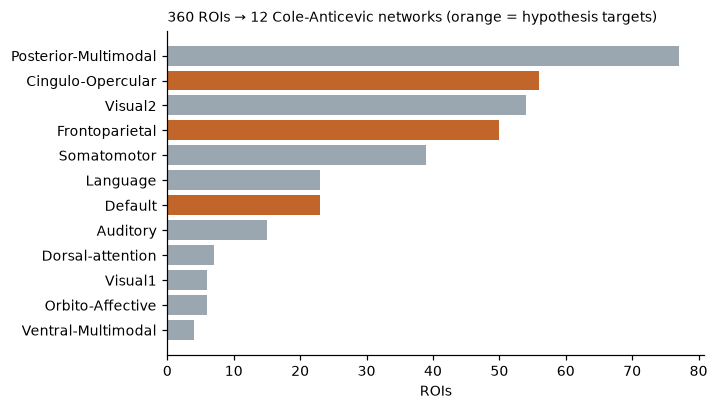

,n_rois
network,
Posterior-Multimodal,77
Cingulo-Opercular,56
Visual2,54
Frontoparietal,50
Somatomotor,39
Language,23
Default,23
Auditory,15
Dorsal-attention,7


In [4]:
counts = reg_A["network"].value_counts()
targets = {"Frontoparietal", "Cingulo-Opercular", "Default"}
colors = [C_B if n in targets else "#9aa7b1" for n in counts.index]
fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.barh(counts.index[::-1], counts.values[::-1], color=colors[::-1])
ax.set_xlabel("ROIs"); ax.set_title("360 ROIs → 12 Cole-Anticevic networks (orange = hypothesis targets)",
                                     loc="left", fontsize=9)
fig.tight_layout(); plt.show()
counts.to_frame("n_rois")

### A.3 · Conditions & EV segmentation

8 conditions = 2 load levels × 4 stimulus categories. The EV files give the frame timing; pooling the 4 categories
and both runs yields the per-condition matrix step 3 consumes. The two loads must not share frames.

In [5]:
frames = {lvl: pp.condition_frames(A, A_subs[0], 0, lvl) for lvl in ["0back", "2back"]}
seg = pd.DataFrame({
    "conditions pooled": [", ".join(ds.COND_0BACK), ", ".join(ds.COND_2BACK)],
    "frames (1 run)": [len(frames["0back"]), len(frames["2back"])],
    "frames/condition (LR+RL)": [pp.condition_timeseries(A, A_subs[0], "0back").shape[1],
                                 pp.condition_timeseries(A, A_subs[0], "2back").shape[1]],
}, index=["0-back", "2-back"])
seg.assign(**{"0-back ∩ 2-back overlap": len(np.intersect1d(frames["0back"], frames["2back"]))})

,conditions pooled,frames (1 run),frames/condition (LR+RL),0-back ∩ 2-back overlap
0-back,"0bk_body, 0bk_faces, 0bk_places, 0bk_tools",156,312,0
2-back,"2bk_body, 2bk_faces, 2bk_places, 2bk_tools",156,312,0


### A.4 · Prediction target (`acc_2bk`)

Parsed per subject from `Stats.txt` via `behaviour_table`. A good target has spread and no missing values.

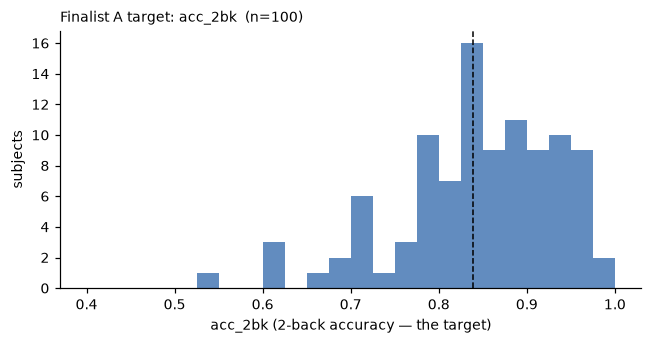

,acc_0bk,acc_2bk,acc_cost,rt_2bk
mean,0.927,0.839,-0.088,1032.301
std,0.077,0.091,0.095,119.747
min,0.638,0.538,-0.388,714.378
max,1.000,0.988,0.250,1257.795


In [6]:
beh_A = pp.behaviour_table(A)
fig, ax = plt.subplots(figsize=(6.0, 3.2))
ax.hist(beh_A.acc_2bk, bins=np.linspace(0.4, 1, 25), color=C_A, alpha=0.8)
ax.axvline(beh_A.acc_2bk.mean(), color="k", ls="--", lw=1)
ax.set_xlabel("acc_2bk (2-back accuracy — the target)"); ax.set_ylabel("subjects")
ax.set_title(f"Finalist A target: acc_2bk  (n={len(beh_A)})", loc="left", fontsize=9)
fig.tight_layout(); plt.show()
beh_A[["acc_0bk", "acc_2bk", "acc_cost", "rt_2bk"]].describe().round(3).loc[["mean", "std", "min", "max"]]

### A.5 · FC reconfiguration

For one subject we build the `(360×360)` functional-connectivity matrix per load (Pearson between ROI time series)
and their difference. **That difference — 2-back minus 0-back — is the feature the whole project predicts from.**

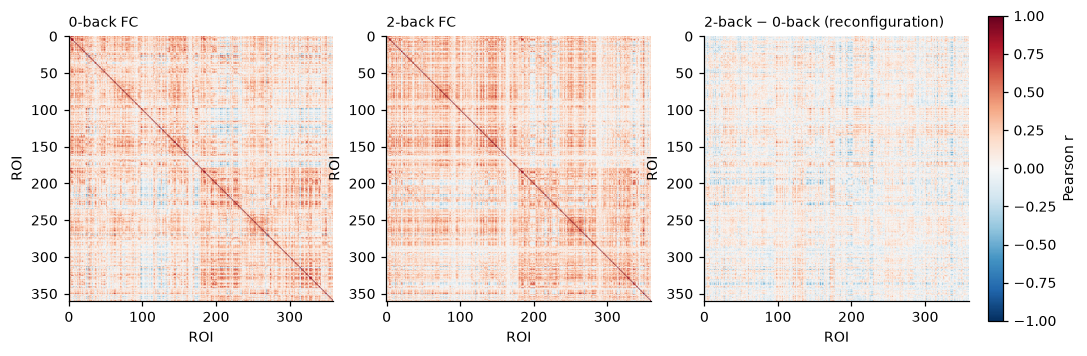

one subject (ID not shown) · FC 360×360 · the reconfiguration map is what step 5/6 turns into a prediction


In [7]:
m0 = pp.condition_timeseries(A, A_subs[0], "0back")
m2 = pp.condition_timeseries(A, A_subs[0], "2back")
fc0, fc2 = np.corrcoef(m0), np.corrcoef(m2)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, M, title in zip(axes, [fc0, fc2, fc2 - fc0],
                        ["0-back FC", "2-back FC", "2-back − 0-back (reconfiguration)"]):
    im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(title, fontsize=9, loc="left"); ax.set_xlabel("ROI"); ax.set_ylabel("ROI")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="Pearson r")
plt.show()
print("one subject (ID not shown) · FC 360×360 · the reconfiguration map is what step 5/6 turns into a prediction")

---
## B · Finalist B — `hcp` (339 subjects, task + resting-state) · *tentative comparison*

Loaded **inline** here (not through the shared `datasets` / `preprocessing` loaders) because B is not yet adopted. Mirrors the A sections where it
matters, and adds the one thing B uniquely unlocks: real resting-state FC.

### B.1 · Load & shape (resting-state)

In [8]:
B_rest = B.rest_dir
B_subs = sorted((p.name for p in (B_rest / "subjects").iterdir() if p.is_dir()), key=lambda s: int(s))
rest_files = sorted(glob.glob(str(B_rest / "subjects" / B_subs[0] / "timeseries" / "bold*.npy")))
ts_B = np.load(rest_files[0])
pd.DataFrame({"value": [len(B_subs), ds.N_PARCELS, len(rest_files), f"{ts_B.shape}"]},
             index=["subjects", "ROIs", "rest runs/subject", "one rest run (ROI×frames)"])

,value
subjects,339
ROIs,360
rest runs/subject,4
one rest run (ROI×frames),"(360, 1200)"


### B.2 · Consolidated `wm.csv`

B ships behaviour as one tidy CSV (per subject × condition), vs A's per-subject `Stats.txt`.

In [9]:
wm = pd.read_csv(B.behaviour)
print("wm.csv shape:", wm.shape, "| columns:", list(wm.columns))
wm.head()

wm.csv shape: (5382, 9) | columns: ['Subject', 'Run', 'ConditionName', 'ACC', 'ACC_NONTARGET', 'ACC_TARGET', 'MEDIAN_RT', 'MEDIAN_RT_NONTARGET', 'MEDIAN_RT_TARGET']


,Subject,Run,ConditionName,ACC,ACC_NONTARGET,ACC_TARGET,MEDIAN_RT,MEDIAN_RT_NONTARGET,MEDIAN_RT_TARGET
0,0,0,0BK_BODY,1.0,1.0,1.0,705.5,740.5,696.0
1,0,0,0BK_FACE,1.0,1.0,1.0,779.5,765.0,915.0
2,0,0,0BK_PLACE,1.0,1.0,1.0,926.0,993.5,811.5
3,0,0,0BK_TOOL,1.0,1.0,1.0,807.5,807.5,807.5
4,0,0,2BK_BODY,1.0,1.0,1.0,1133.0,1205.5,732.5


### B.3 · The prediction target from `wm.csv`

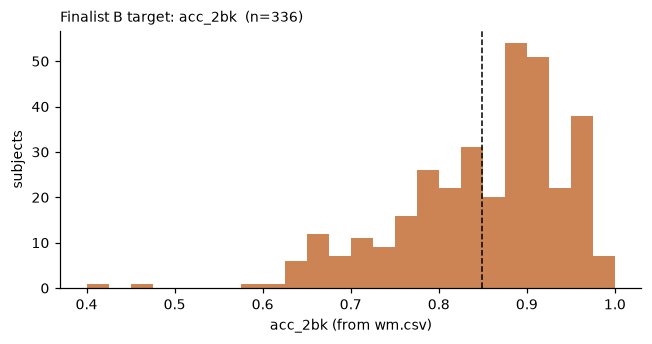

,acc_2bk
count,336.000
mean,0.849
std,0.094
min,0.406
25%,0.797
50%,0.875
75%,0.922
max,1.000


In [10]:
wm["load"] = wm["ConditionName"].str.extract(r"(\dBK)")
accB = wm.groupby(["Subject", "load"])["ACC"].mean().unstack()
beh_B_acc2 = accB["2BK"].dropna()
fig, ax = plt.subplots(figsize=(6.0, 3.2))
ax.hist(beh_B_acc2, bins=np.linspace(0.4, 1, 25), color=C_B, alpha=0.8)
ax.axvline(beh_B_acc2.mean(), color="k", ls="--", lw=1)
ax.set_xlabel("acc_2bk (from wm.csv)"); ax.set_ylabel("subjects")
ax.set_title(f"Finalist B target: acc_2bk  (n={len(beh_B_acc2)})", loc="left", fontsize=9)
fig.tight_layout(); plt.show()
beh_B_acc2.describe().round(3).to_frame("acc_2bk")

### B.4 · Resting-state FC (abstract Objective 2)

One sample rest run → one `(360×360)` FC matrix. The warm on-diagonal blocks are within-network coupling: the
expected signature of real resting-state FC, which Finalist A does not have.

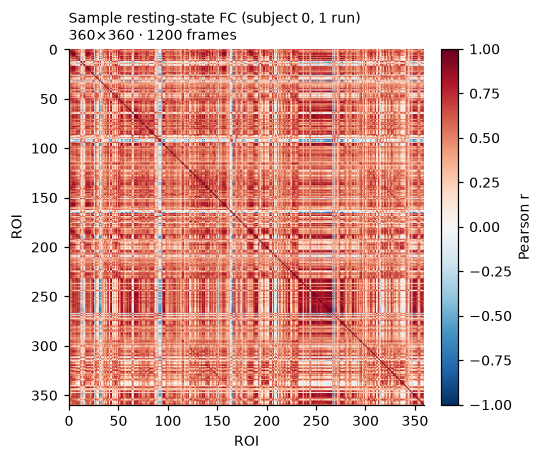

mean |r| off-diagonal: 0.469


In [11]:
ts = ts_B - ts_B.mean(axis=1, keepdims=True)
fc_rest = np.corrcoef(ts)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(fc_rest, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_title(f"Sample resting-state FC (subject {B_subs[0]}, 1 run)\n360×360 · {ts.shape[1]} frames",
             loc="left", fontsize=9)
ax.set_xlabel("ROI"); ax.set_ylabel("ROI")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
plt.show()
print("mean |r| off-diagonal:", round(np.abs(fc_rest[np.triu_indices(360, 1)]).mean(), 3))

### B.5 · Atlas geometry (`hcp_atlas_339.npz`)

B ships the atlas from the data dictionary: `coords (360, 3)` (ROI centroids in MNI) + the
`labels_R`/`labels_L` surface vertex→ROI maps. A quick axial look confirms the 360 nodes form the
expected brain layout — the node geometry for the graph team, and the surface route for painting
per-ROI values later.

{'labels_R': (10242,), 'labels_L': (10242,), 'coords': (360, 3)}


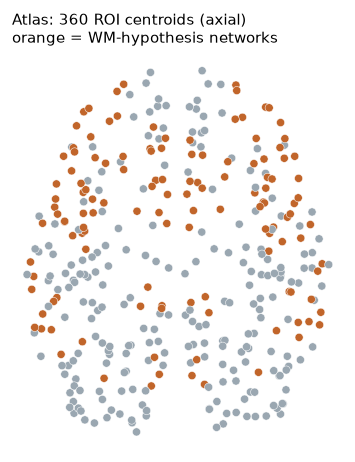

In [ ]:
# Atlas geometry — B ships hcp_atlas_339.npz. Confirm the data-dictionary shapes, then look at the layout.
atlas = np.load(B.atlas)
print({k: atlas[k].shape for k in atlas.files})              # coords (360,3) · labels_R/L (10242,)

reg_B = pp.region_table(B)
xy = atlas["coords"][:, :2]                                  # axial (top-down) view
targets = {"Frontoparietal", "Cingulo-Opercular", "Default"}
color = [C_B if n in targets else "#9aa7b1" for n in reg_B["network"]]
fig, ax = plt.subplots(figsize=(4.4, 4.3))
ax.scatter(xy[:, 0], xy[:, 1], s=24, c=color, edgecolors="white", linewidths=0.3)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Atlas: 360 ROI centroids (axial)\norange = WM-hypothesis networks", loc="left", fontsize=9)
plt.show()

---
## A vs B — target side by side

The decision lens: both finalists give a well-spread, comparable target (mean ≈ 0.84). B simply offers 3.4× more
subjects and resting-state, at the cost of a re-ingest (see `00` for the costed A/B/C options).

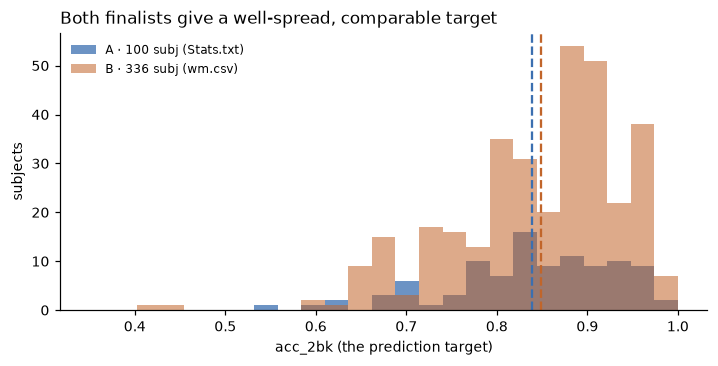

In [12]:
fig, ax = plt.subplots(figsize=(6.6, 3.4))
bins = np.linspace(0.35, 1.0, 26)
ax.hist(beh_A.acc_2bk, bins=bins, color=C_A, alpha=0.75, label=f"A · {len(beh_A)} subj (Stats.txt)")
ax.hist(beh_B_acc2,    bins=bins, color=C_B, alpha=0.55, label=f"B · {len(beh_B_acc2)} subj (wm.csv)")
ax.axvline(beh_A.acc_2bk.mean(), color=C_A, ls="--", lw=1.5)
ax.axvline(beh_B_acc2.mean(),    color=C_B, ls="--", lw=1.5)
ax.set_xlabel("acc_2bk (the prediction target)"); ax.set_ylabel("subjects")
ax.set_title("Both finalists give a well-spread, comparable target", loc="left")
ax.legend(frameon=False, fontsize=8); fig.tight_layout(); plt.show()

---
## Data dictionary

| Object | Shape / form | What it is | Loader |
|---|---|---|---|
| `regions.npy` → region table | 360 rows | ROI name, network, hemisphere | `region_table` |
| `data.npy` (WM) | `(360 × ~405)` | parcellated BOLD, mean-removed | `load_timeseries` |
| `EVs/<cond>.txt` | `(onset, dur, amp)` | condition timing (seconds) | `condition_frames` |
| `EVs/Stats.txt` (A) | `label: value` | behaviour per run (ACC, RT) | `_parse_stats` / `behaviour_table` |
| `behavior/wm.csv` (B) | tidy rows | per-condition ACC/RT, consolidated | `pandas.read_csv` |
| rest `bold*.npy` (B) | `(360 × 1200)` | resting-state BOLD, 4 runs | `numpy.load` |

## What each object can / cannot answer

| Resource | ✅ Good for | ❌ Not for |
|---|---|---|
| WM `data.npy` + EVs | per-condition FC, 0→2-back reconfiguration | resting-state (absent in Finalist A) |
| `Stats.txt` / `wm.csv` | WM performance target (ACC / RT) | fine trial-level modelling |
| B rest `bold*.npy` | intrinsic FC (abstract Objective 2) | task-condition contrasts |

**Closed:** target `acc_2bk` (both finalists, wide spread); 312 frames/condition (A); truncated network labels
handled. **Open (team):** dataset A vs B (`00`), graph thresholding, prediction model.